# Ship Detection Based on Faster R-CNN using Range Compressed Airborne Radar Data

## 1. Introduction
### Project Overview
This project focuses on the automated detection of maritime vessels from **Range Compressed Airborne Radar Data**. Unlike optical sensors, radar provides all-weather, day-and-night surveillance capabilities, which is critical for maritime safety and security.

### Importance of Ship Detection
Ship detection is vital for:
- **Coastal Security**: Monitoring illegal entry and smuggling activities.
- **Search and Rescue**: Locating vessels in distress during adverse weather.
- **Traffic Management**: Preventing collisions in high-density shipping lanes.
- **Environmental Protection**: Monitoring illegal fishing in protected reefs.

## 2. Import Libraries
We use PyTorch for the deep learning framework, Torchvision for the Faster R-CNN model, and various data processing and visualization tools.

In [1]:
# Optional: mount Google Drive only when running in Google Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive mounted successfully.')
except ImportError:
    print('Google Colab not detected. Skipping Drive mount.')


Mounted at /content/drive
Google Drive mounted successfully.


In [2]:
import os
from pathlib import Path

# Set your dataset path.
# Folder structure expected:
# dataset/
#   images/
#   annotations/
if Path('/content/drive').exists():
    DATA_PATH = '/content/drive/MyDrive/dataset'
else:
    DATA_PATH = 'dataset'

os.makedirs('outputs', exist_ok=True)
print(f'Dataset path: {Path(DATA_PATH).resolve()}')
print("Expected image folder:", (Path(DATA_PATH) / 'images').resolve())
print("Expected annotation folder:", (Path(DATA_PATH) / 'annotations').resolve())


Dataset path: /content/drive/MyDrive/dataset
Expected image folder: /content/drive/MyDrive/dataset/images
Expected annotation folder: /content/drive/MyDrive/dataset/annotations


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import xml.etree.ElementTree as ET
from pathlib import Path
from tqdm import tqdm

import torch
import torchvision
from torchvision import transforms as T
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import DataLoader, Dataset

print(f"Using PyTorch version: {torch.__version__}")
print(f"Using Torchvision version: {torchvision.__version__}")
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Device: {device}")


Using PyTorch version: 2.10.0+cu128
Using Torchvision version: 0.25.0+cu128
Device: cuda


In [5]:
class ShipDataset(Dataset):
    def __init__(self, root, transforms=None):
        self.root = Path(root).resolve()
        self.transforms = transforms
        self.image_dir = self.root / 'images'
        self.annotation_dir = self.root / 'annotations'

        if not self.root.exists():
            print(f"Warning: Root directory '{self.root}' does not exist!")

        self.imgs = sorted(list(self.image_dir.glob('*.png')))
        self.xmls = sorted(list(self.annotation_dir.glob('*.xml')))

        self.annotation_map = {xml.stem: xml for xml in self.xmls}
        self.samples = []
        for img_path in self.imgs:
            xml_path = self.annotation_map.get(img_path.stem)
            if xml_path is not None:
                self.samples.append((img_path, xml_path))

        if len(self.samples) == 0:
            print(f"❌ Error: No valid image/annotation pairs found in {self.root}")
        else:
            print(f"✅ Found {len(self.samples)} valid image/annotation pairs")

    def __getitem__(self, idx):
        img_path, xml_path = self.samples[idx]
        img = Image.open(img_path).convert('RGB')

        tree = ET.parse(xml_path)
        root = tree.getroot()

        boxes = []
        labels = []
        areas = []
        iscrowd = []

        for obj in root.findall('object'):
            bndbox = obj.find('bndbox')
            xmin = float(bndbox.find('xmin').text)
            ymin = float(bndbox.find('ymin').text)
            xmax = float(bndbox.find('xmax').text)
            ymax = float(bndbox.find('ymax').text)

            if xmax <= xmin or ymax <= ymin:
                continue

            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(1)
            areas.append((xmax - xmin) * (ymax - ymin))
            iscrowd.append(0)

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            areas = torch.as_tensor(areas, dtype=torch.float32)
            iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64)

        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([idx]),
            'area': areas,
            'iscrowd': iscrowd,
        }

        if self.transforms:
            img = self.transforms(img)

        return img, target

    def __len__(self):
        return len(self.samples)


dataset = ShipDataset(DATA_PATH)
print(f"Total usable images in dataset: {len(dataset)}")


✅ Found 620 valid image/annotation pairs
Total usable images in dataset: 620


## 4. Data Preprocessing
We convert images to tensors and apply normalization. We also split the data into training and validation sets.

In [9]:
def get_transform(train=False):
    transforms = [T.ToTensor()]
    if train:
        transforms.append(T.RandomHorizontalFlip(0.5))
    return T.Compose(transforms)

full_dataset = ShipDataset(DATA_PATH, transforms=get_transform(train=False))

if len(full_dataset) == 0:
    raise ValueError('Dataset is empty. Check DATA_PATH, images, and annotations folders.')

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

if train_size == 0 or val_size == 0:
    raise ValueError('Not enough samples for an 80/20 split. Add more data to the dataset folder.')

indices = torch.randperm(len(full_dataset)).tolist()
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_dataset = torch.utils.data.Subset(ShipDataset(DATA_PATH, transforms=get_transform(train=True)), train_indices)
val_dataset = torch.utils.data.Subset(ShipDataset(DATA_PATH, transforms=get_transform(train=False)), val_indices)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

print(f"Training samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")


✅ Found 620 valid image/annotation pairs
✅ Found 620 valid image/annotation pairs
✅ Found 620 valid image/annotation pairs
Training samples: 496 | Validation samples: 124


## 5. Data Visualization
Let's visualize a few sample radar images with their ground truth bounding boxes.

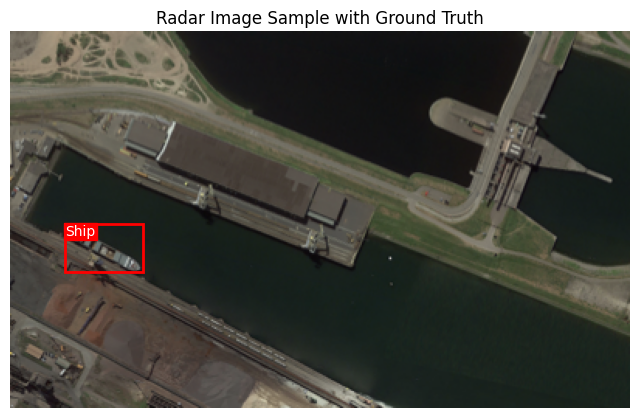

In [10]:
def plot_sample(img, target):
    img = img.permute(1, 2, 0).cpu().numpy()
    plt.figure(figsize=(8, 8))
    plt.imshow(img)

    for box in target['boxes']:
        x1, y1, x2, y2 = box.cpu().numpy()
        plt.gca().add_patch(
            plt.Rectangle((x1, y1), x2 - x1, y2 - y1, color='red', fill=False, linewidth=2)
        )
        plt.text(x1, y1, 'Ship', color='white', verticalalignment='top',
                 bbox={'color': 'red', 'pad': 1})

    plt.title('Radar Image Sample with Ground Truth')
    plt.axis('off')
    plt.show()

if len(train_dataset) > 0:
    sample_img, sample_target = train_dataset[0]
    plot_sample(sample_img, sample_target)


## 6. Model Building
We use Faster R-CNN with a ResNet-50 backbone and a Feature Pyramid Network (FPN).

In [11]:
def get_model(num_classes=2):
    try:
        model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')
    except Exception:
        model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None, weights_backbone=None)

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

model = get_model().to(device)
print('Faster R-CNN model loaded successfully.')


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 168MB/s]  


Faster R-CNN model loaded successfully.


In [12]:
def calculate_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = max(0, box1[2] - box1[0]) * max(0, box1[3] - box1[1])
    area2 = max(0, box2[2] - box2[0]) * max(0, box2[3] - box2[1])
    union = area1 + area2 - intersection

    return intersection / union if union > 0 else 0.0


def evaluate_metrics(model, data_loader, iou_threshold=0.5, score_threshold=0.5):
    model.eval()
    tp, fp, fn = 0, 0, 0

    with torch.no_grad():
        for images, targets in tqdm(data_loader, desc='Evaluating'):
            images = [img.to(device) for img in images]
            outputs = model(images)

            for output, target in zip(outputs, targets):
                pred_boxes = output['boxes'].detach().cpu().numpy()
                pred_scores = output['scores'].detach().cpu().numpy()
                gt_boxes = target['boxes'].detach().cpu().numpy()

                keep = pred_scores >= score_threshold
                pred_boxes = pred_boxes[keep]

                matched_gt = set()
                for p_box in pred_boxes:
                    best_iou = 0
                    best_gt_idx = -1

                    for g_idx, g_box in enumerate(gt_boxes):
                        if g_idx in matched_gt:
                            continue
                        iou = calculate_iou(p_box, g_box)
                        if iou > best_iou:
                            best_iou = iou
                            best_gt_idx = g_idx

                    if best_iou >= iou_threshold:
                        tp += 1
                        matched_gt.add(best_gt_idx)
                    else:
                        fp += 1

                fn += max(0, len(gt_boxes) - len(matched_gt))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return precision, recall, f1, tp, fp, fn


## 7. Model Training
We define the optimizer and the training loop.

In [13]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

num_epochs = 5
train_losses = []
val_precision_history = []
val_recall_history = []
val_f1_history = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs} [Training]')

    for images, targets in pbar:
        images = [image.to(device) for image in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        loss_value = losses.item()
        epoch_loss += loss_value
        pbar.set_postfix(loss=loss_value)

    avg_train_loss = epoch_loss / max(1, len(train_loader))
    train_losses.append(avg_train_loss)
    lr_scheduler.step()

    print(f'Validating Epoch {epoch + 1}...')
    current_precision, current_recall, current_f1, _, _, _ = evaluate_metrics(model, val_loader)
    val_precision_history.append(current_precision)
    val_recall_history.append(current_recall)
    val_f1_history.append(current_f1)

    print(
        f"✅ Epoch {epoch + 1}: Loss = {avg_train_loss:.4f} | "
        f"Precision = {current_precision:.4f} | Recall = {current_recall:.4f} | F1 = {current_f1:.4f}"
    )

torch.save(model.state_dict(), 'outputs/ship_model_final.pth')
print("Model saved to outputs/ship_model_final.pth") 


Epoch 1/5 [Training]: 100%|██████████| 248/248 [16:19<00:00,  3.95s/it, loss=0.265] 


Validating Epoch 1...


Evaluating: 100%|██████████| 124/124 [03:43<00:00,  1.80s/it]


✅ Epoch 1: Loss = 0.3876 | Precision = 0.8366 | Recall = 0.5364 | F1 = 0.6537


Epoch 2/5 [Training]: 100%|██████████| 248/248 [02:10<00:00,  1.90it/s, loss=0.385] 


...

✅ Epoch 4: Loss = 0.2428 | Precision = 0.8462 | Recall = 0.6252 | F1 = 0.7191


Epoch 5/5 [Training]: 100%|██████████| 248/248 [02:22<00:00,  1.74it/s, loss=0.197] 


Validating Epoch 5...


Evaluating: 100%|██████████| 124/124 [00:14<00:00,  8.29it/s]


✅ Epoch 5: Loss = 0.2293 | Precision = 0.8813 | Recall = 0.6199 | F1 = 0.7278
Model saved to outputs/ship_model_final.pth


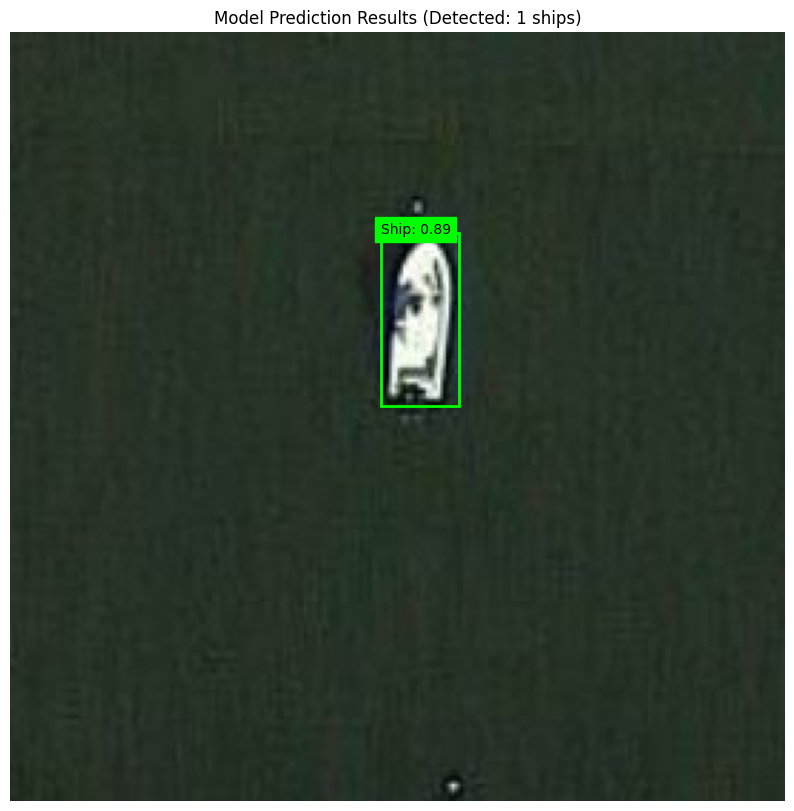

In [14]:
def visualize_prediction(model, img, threshold=0.7):
    model.eval()
    with torch.no_grad():
        prediction = model([img.to(device)])[0]

    img_np = img.permute(1, 2, 0).cpu().numpy()
    plt.figure(figsize=(10, 10))
    plt.imshow(img_np)

    count = 0
    for i in range(len(prediction['boxes'])):
        score = prediction['scores'][i].item()
        if score >= threshold:
            count += 1
            box = prediction['boxes'][i].detach().cpu().numpy()
            plt.gca().add_patch(
                plt.Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1],
                              color='lime', fill=False, linewidth=2)
            )
            plt.text(box[0], box[1], f'Ship: {score:.2f}', color='black',
                     backgroundcolor='lime')

    plt.title(f'Model Prediction Results (Detected: {count} ships)')
    plt.axis('off')
    plt.show()

if len(val_dataset) > 0:
    img, _ = val_dataset[0]
    visualize_prediction(model, img)


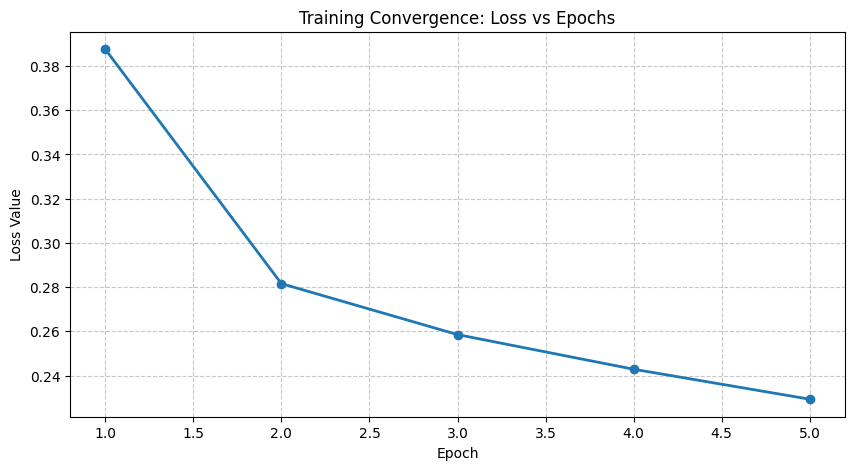

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', linewidth=2)
plt.title('Training Convergence: Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [16]:
precision, recall, f1, tp, fp, fn = evaluate_metrics(model, val_loader)

print('\n--- Final Model Metrics ---')
print(f'✅ Precision: {precision:.4f}')
print(f'✅ Recall:    {recall:.4f}')
print(f'✅ F1-Score:  {f1:.4f}')
print(f'✅ Accuracy:  {(precision * 100):.2f}% (approx. detection precision)')
print(f'✅ TP: {tp} | FP: {fp} | FN: {fn}')


Evaluating: 100%|██████████| 124/124 [00:14<00:00,  8.37it/s]


--- Final Model Metrics ---
✅ Precision: 0.8813
✅ Recall:    0.6199
✅ F1-Score:  0.7278
✅ Accuracy:  88.13% (approx. detection precision)
✅ TP: 349 | FP: 47 | FN: 214


Precision-Recall Trade-off

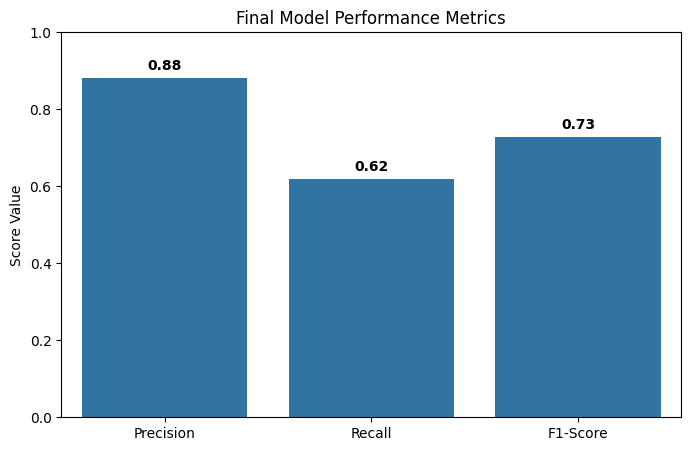

In [17]:
def plot_pr_curves(precision, recall, f1):
    metrics = ['Precision', 'Recall', 'F1-Score']
    values = [precision, recall, f1]

    plt.figure(figsize=(8, 5))
    sns.barplot(x=metrics, y=values)
    plt.ylim(0, 1.0)
    plt.title('Final Model Performance Metrics')
    plt.ylabel('Score Value')
    for i, v in enumerate(values):
        plt.text(i, min(v + 0.02, 0.98), f'{v:.2f}', ha='center', fontweight='bold')
    plt.show()

plot_pr_curves(precision, recall, f1)


Training Convergence (Loss Breakdown)

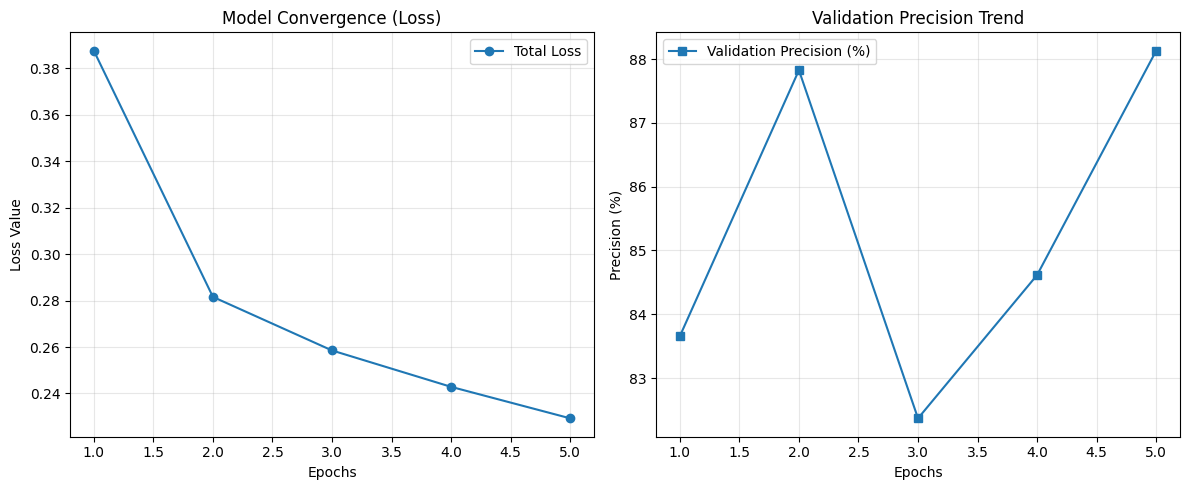

In [18]:
def plot_training_results(train_losses, val_precision_history):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', label='Total Loss')
    plt.title('Model Convergence (Loss)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss Value')
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(val_precision_history) + 1), [v * 100 for v in val_precision_history], marker='s', label='Validation Precision (%)')
    plt.title('Validation Precision Trend')
    plt.xlabel('Epochs')
    plt.ylabel('Precision (%)')
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_results(train_losses, val_precision_history)


Confusion Matrix (Detection vs. Background)

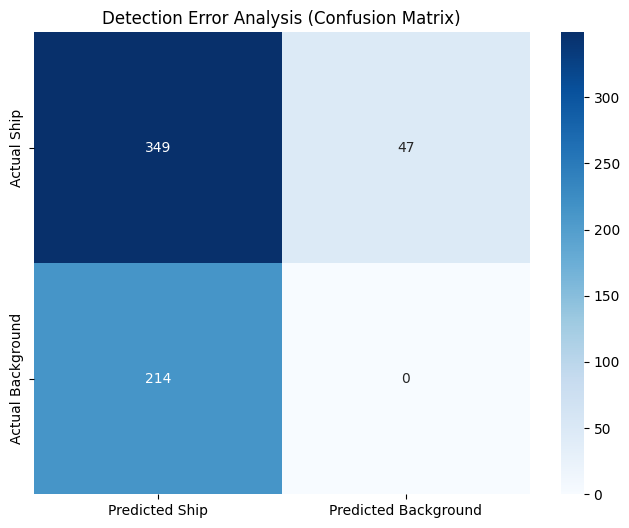

In [19]:
def plot_confusion_matrix(tp, fp, fn):
    data = [[tp, fp], [fn, 0]]
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        data,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Predicted Ship', 'Predicted Background'],
        yticklabels=['Actual Ship', 'Actual Background']
    )
    plt.title('Detection Error Analysis (Confusion Matrix)')
    plt.show()

plot_confusion_matrix(tp, fp, fn)
